In [1]:
# Install R + Rpy2 for Colab
!apt-get update -qq
!apt-get install -y r-base

!Rscript -e "install.packages(c('recommenderlab','data.table','ggplot2','reshape2'), repos='https://cloud.r-project.org')"
!pip install rpy2


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.2-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 54 not upgraded.
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘float’, ‘RcppProgress’, ‘arules’, ‘proxy’, ‘registry’, ‘irlba’, ‘recosystem’, ‘matrixStats’, ‘plyr’

trying URL 'https://cloud.r-project.org/src/contrib/float_0.3-3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RcppProgress_0.4.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/arules_1.7.13.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/proxy_0.4-29.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/registry_0.5-1.tar.gz'
tryi

In [2]:
%load_ext rpy2.ipython


In [3]:
%%R
library(recommenderlab)
library(ggplot2)
library(data.table)
library(reshape2)


Loading required package: Matrix
Loading required package: arules

Attaching package: ‘arules’

The following objects are masked from ‘package:base’:

    abbreviate, write

Loading required package: proxy

Attaching package: ‘proxy’

The following object is masked from ‘package:Matrix’:

    as.matrix

The following objects are masked from ‘package:stats’:

    as.dist, dist

The following object is masked from ‘package:base’:

    as.matrix

data.table 1.18.2.1 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘reshape2’

The following objects are masked from ‘package:data.table’:

    dcast, melt



In [4]:
from google.colab import files
uploaded = files.upload()


Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv


In [5]:
%%R
movie_data <- read.csv("movies.csv", stringsAsFactors = FALSE)
rating_data <- read.csv("ratings.csv")

head(movie_data)
head(rating_data)


  userId movieId rating  timestamp
1      1      16    4.0 1217897793
2      1      24    1.5 1217895807
3      1      32    4.0 1217896246
4      1      47    4.0 1217896556
5      1      50    4.0 1217896523
6      1     110    4.0 1217896150


In [6]:
%%R
movie_genre <- as.data.frame(movie_data$genres, stringsAsFactors = FALSE)
movie_genre2 <- as.data.frame(tstrsplit(movie_genre[,1], '[|]', type.convert=TRUE),
                             stringsAsFactors = FALSE)

list_genre <- c("Action","Adventure","Animation","Children","Comedy",
                "Crime","Documentary","Drama","Fantasy","Film-Noir",
                "Horror","Musical","Mystery","Romance","Sci-Fi",
                "Thriller","War","Western")

genre_mat1 <- matrix(0, nrow(movie_data), length(list_genre))
colnames(genre_mat1) <- list_genre

for (i in 1:nrow(movie_genre2)) {
  for (j in 1:ncol(movie_genre2)) {
    gen_col = which(list_genre == movie_genre2[i,j])
    genre_mat1[i, gen_col] <- 1
  }
}

genre_mat2 <- as.data.frame(genre_mat1)
SearchMatrix <- cbind(movie_data[,1:2], genre_mat2)

head(SearchMatrix)


  movieId                              title Action Adventure Animation
1       1                   Toy Story (1995)      0         1         1
2       2                     Jumanji (1995)      0         1         0
3       3            Grumpier Old Men (1995)      0         0         0
4       4           Waiting to Exhale (1995)      0         0         0
5       5 Father of the Bride Part II (1995)      0         0         0
6       6                        Heat (1995)      1         0         0
  Children Comedy Crime Documentary Drama Fantasy Film-Noir Horror Musical
1        1      1     0           0     0       1         0      0       0
2        1      0     0           0     0       1         0      0       0
3        0      1     0           0     0       0         0      0       0
4        0      1     0           0     1       0         0      0       0
5        0      1     0           0     0       0         0      0       0
6        0      0     1           0     0     

In [7]:
%%R
ratingMatrix <- dcast(rating_data, userId ~ movieId, value.var = "rating", na.rm = FALSE)
ratingMatrix <- as.matrix(ratingMatrix[,-1])
ratingMatrix <- as(ratingMatrix, "realRatingMatrix")

ratingMatrix


668 x 10325 rating matrix of class ‘realRatingMatrix’ with 105339 ratings.


In [8]:
%%R
similarity_users <- similarity(ratingMatrix[1:4,], method="cosine", which="users")
as.matrix(similarity_users)

similarity_movies <- similarity(ratingMatrix[,1:4], method="cosine", which="items")
as.matrix(similarity_movies)


          1         2         3         4
1        NA 0.9834866 0.9779671 0.9550638
2 0.9834866        NA 0.9829378 0.9706208
3 0.9779671 0.9829378        NA 0.9932438
4 0.9550638 0.9706208 0.9932438        NA


In [9]:
%%R
rating_values <- as.vector(ratingMatrix@data)
unique(rating_values)
table_of_ratings <- table(rating_values)
table_of_ratings


rating_values
      0     0.5       1     1.5       2     2.5       3     3.5       4     4.5 
6791761    1198    3258    1567    7943    5484   21729   12237   28880    8187 
      5 
  14856 


In [10]:
%%R
movie_views <- colCounts(ratingMatrix)
table_views <- data.frame(movie = names(movie_views), views = movie_views)
table_views <- table_views[order(table_views$views, decreasing = TRUE),]
table_views$title <- sapply(table_views$movie, function(x) {
  as.character(subset(movie_data, movieId == x)$title)
})
table_views[1:6,]


    movie views                                     title
296   296   325                       Pulp Fiction (1994)
356   356   311                       Forrest Gump (1994)
318   318   308          Shawshank Redemption, The (1994)
480   480   294                      Jurassic Park (1993)
593   593   290          Silence of the Lambs, The (1991)
260   260   273 Star Wars: Episode IV - A New Hope (1977)


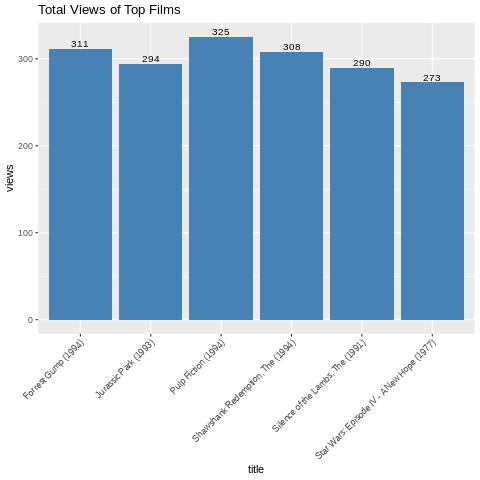

In [11]:
%%R
ggplot(table_views[1:6,], aes(x=title, y=views)) +
  geom_bar(stat="identity", fill='steelblue') +
  geom_text(aes(label=views), vjust=-0.3, size=3.5) +
  theme(axis.text.x = element_text(angle=45, hjust=1)) +
  ggtitle("Total Views of Top Films")


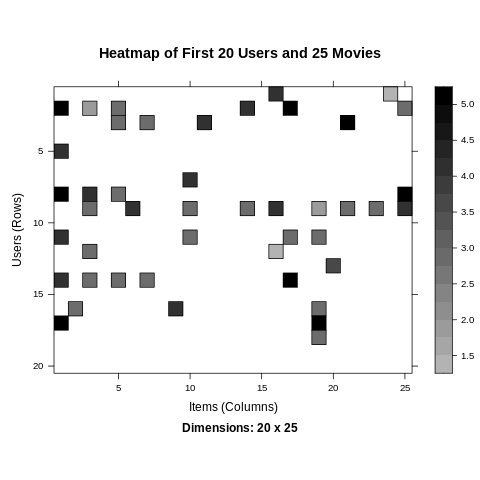

In [12]:
%%R
image(ratingMatrix[1:20, 1:25], axes=FALSE,
      main="Heatmap of First 20 Users and 25 Movies")


In [13]:
%%R
movie_ratings <- ratingMatrix[rowCounts(ratingMatrix) > 50,
                              colCounts(ratingMatrix) > 50]
movie_ratings


420 x 447 rating matrix of class ‘realRatingMatrix’ with 38341 ratings.


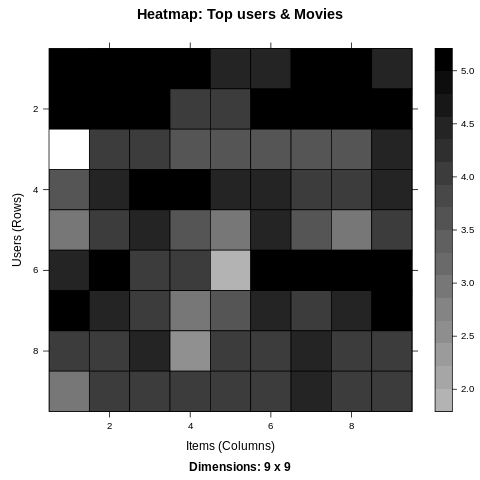

In [14]:
%%R
minimum_movies <- quantile(rowCounts(movie_ratings), 0.98)
minimum_users <- quantile(colCounts(movie_ratings), 0.98)

image(movie_ratings[rowCounts(movie_ratings) > minimum_movies,
                    colCounts(movie_ratings) > minimum_users],
      main="Heatmap: Top users & Movies")


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


In addition: Warning message:
`qplot()` was deprecated in ggplot2 3.4.0.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


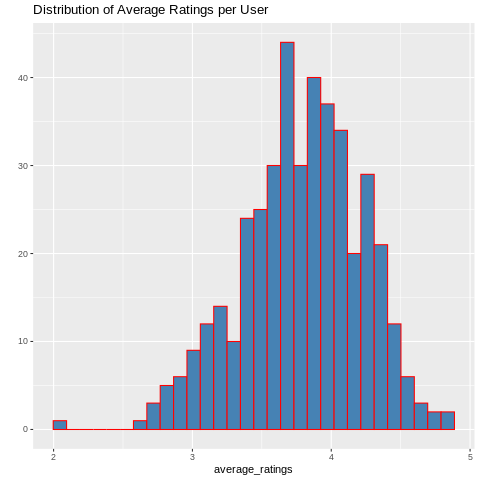

In [15]:
%%R
average_ratings <- rowMeans(movie_ratings)
qplot(average_ratings, fill=I("steelblue"), col=I("red")) +
  ggtitle("Distribution of Average Ratings per User")


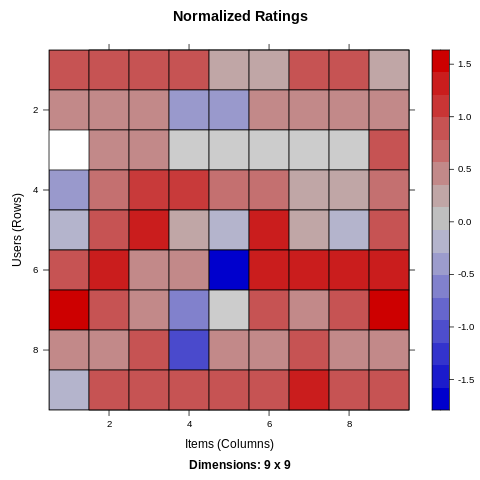

In [16]:
%%R
normalized_ratings <- normalize(movie_ratings)
image(normalized_ratings[rowCounts(normalized_ratings) > minimum_movies,
                         colCounts(normalized_ratings) > minimum_users],
      main="Normalized Ratings")


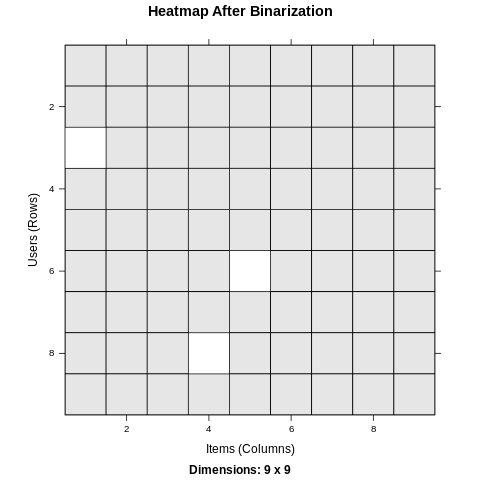

In [17]:
%%R
good_rated_films <- binarize(movie_ratings, minRating = 3)
image(good_rated_films[rowCounts(movie_ratings) > minimum_movies,
                       colCounts(movie_ratings) > minimum_users],
      main="Heatmap After Binarization")


In [18]:
%%R
set.seed(123)
sampled_data <- sample(c(TRUE, FALSE), size=nrow(movie_ratings),
                       replace=TRUE, prob=c(0.8, 0.2))

training_data <- movie_ratings[sampled_data,]
testing_data <- movie_ratings[!sampled_data,]


In [19]:
%%R
recommen_model <- Recommender(data = training_data,
                              method = "IBCF",
                              parameter = list(k=30))
recommen_model


Recommender of type ‘IBCF’ for ‘realRatingMatrix’ 
learned using 341 users.


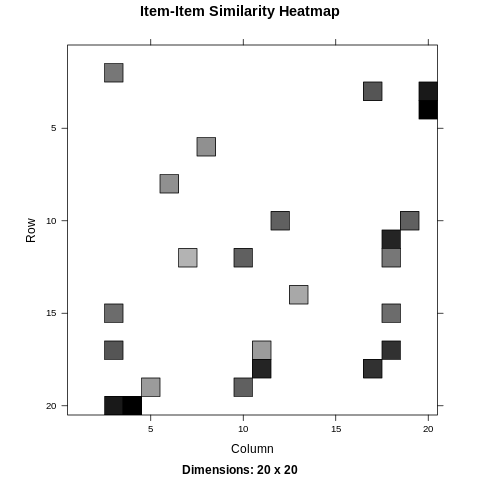

In [20]:
%%R
model_info <- getModel(recommen_model)
dim(model_info$sim)
image(model_info$sim[1:20, 1:20],
      main="Item-Item Similarity Heatmap")


In [21]:
%%R
predicted_recommendations <- predict(object = recommen_model,
                                     newdata = testing_data,
                                     n = 10)

predicted_recommendations


Recommendations as ‘topNList’ with n = 10 for 79 users. 


In [22]:
%%R
user1 <- predicted_recommendations@items[[1]]
movies_user1 <- predicted_recommendations@itemLabels[user1]
movies_user2 <- sapply(movies_user1, function(x) {
  as.character(subset(movie_data, movie_data$movieId == x)$title)
})
movies_user2


                                   6                                  474 
                       "Heat (1995)"         "In the Line of Fire (1993)" 
                                 529                                  541 
"Searching for Bobby Fischer (1993)"                "Blade Runner (1982)" 
                                 593                                  903 
  "Silence of the Lambs, The (1991)"                     "Vertigo (1958)" 
                                 908                                  913 
         "North by Northwest (1959)"         "Maltese Falcon, The (1941)" 
                                 923                                 1036 
               "Citizen Kane (1941)"                    "Die Hard (1988)" 
